### ==============================================================================
## Processing of Moving Vessel Profiler Data - code 2
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from BioSWOT experiment
# 
**DESCRIPTION**:
 This script performs Step 2: Lag Analysis. It calculates the fractional lag 
 between Temperature and Conductivity sensors to correct for spatial/temporal 
 mismatch. It segments the profiles into windows and computes the cross-correlation. 
 For FaSt-SWOT Leg 1, it automatically classifies profiles into 'Normal' and 
 'Anomaly' regimes based on median lag thresholds (handling dirty sensor events).
 Finally, it fits a linear regression model (Lag vs. Descent Rate w) for each regime.
#
 INPUT: QC'd NetCDF files from Step 1 (*_step1_qc.nc).
 #
 OUTPUT: CSV with profile regimes, CSV with lag models, and a 3-panel validation plot.
### ==============================================================================

c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\envs\env_elisabet\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


 [BioSWOT] Processing segments...
  > BioSWOT: Processing 633 files

 [BioSWOT] Ajustando Modelo Único...
✅ Model saved to C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing\Figures\STEP2_LAG_ANALYSIS_FINAL\lag_models_step2.csv
   Equation: Lag = 0.0181 * w + 0.0719


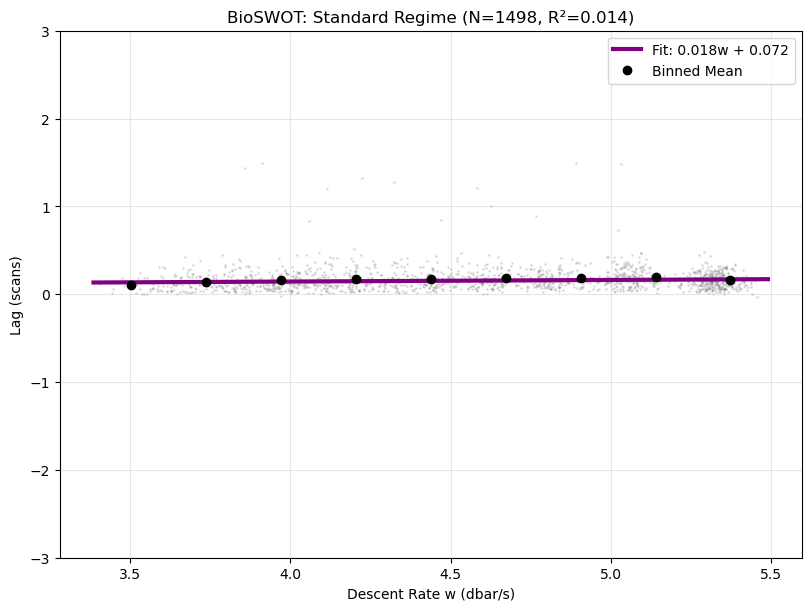

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_ROOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing")

DIRS = {
    "BioSWOT": BASE_ROOT / "Data" / "processed_step1_highres_qc",
}

OUT_DIR = BASE_ROOT / "Figures" / "STEP2_LAG_ANALYSIS_FINAL"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_MODELS_CSV = OUT_DIR / "lag_models_step2.csv"
OUT_SEGMENTS_CSV = OUT_DIR / "lag_per_segment_bioswot.csv"

# --- PARAMETERS ---
WINDOW_SIZE = 125
MAX_LAG_SEARCH = 2
MIN_CORR = 0.8
MIN_GRADIENT = 1e-4

# ==========================================
# 2. FUNCTIONS
# ==========================================
def calculate_fractional_lag(t_seg, c_seg):
    """Calculates fractional lag between two segments using cross-correlation and parabolic fit."""
    t_seg = t_seg - np.mean(t_seg)
    c_seg = c_seg - np.mean(c_seg)
    lags = np.arange(-MAX_LAG_SEARCH, MAX_LAG_SEARCH + 1)
    corrs = []
    
    for lag in lags:
        if lag < 0:
            c_shift = c_seg[-lag:]; t_cut = t_seg[:len(c_shift)]
        elif lag > 0:
            c_shift = c_seg[:-lag]; t_cut = t_seg[lag:]
        else:
            c_shift = c_seg; t_cut = t_seg
            
        if len(c_shift) > 10:
            norm = np.std(t_cut) * np.std(c_shift)
            val = np.mean(t_cut * c_shift) / norm if norm > 1e-9 else 0
        else: val = 0
        corrs.append(val)
        
    corrs = np.array(corrs)
    idx_max = np.argmax(corrs)
    max_corr = corrs[idx_max]
    
    if 0 < idx_max < len(corrs) - 1:
        y = corrs[idx_max-1 : idx_max+2]
        x = lags[idx_max-1 : idx_max+2]
        try:
            coeffs = np.polyfit(x, y, 2)
            a, b, c_poly = coeffs
            if a < 0: return -b / (2 * a), max_corr
        except: pass
    return float(lags[idx_max]), max_corr

def process_segments():
    results = []
    print(f" [BioSWOT] Processing segments...")
    
    for campaign, path in DIRS.items():
        if not path.exists(): 
            print(f"⚠️ path not found: {path}"); continue
            
        files = sorted(list(path.glob("*.nc")))
        print(f"  > {campaign}: Processing {len(files)} files")
        
        for f in files:
            try:
                ds = xr.open_dataset(f)
                if 't1' not in ds: ds.close(); continue
                p, t, c, w = ds['pressure'].values, ds['t1'].values, ds['c1'].values, ds['w_descent'].values
                ds.close()
                
                for i in range(0, len(p) - WINDOW_SIZE, WINDOW_SIZE):
                    t_seg = t[i : i+WINDOW_SIZE]
                    if np.isnan(t_seg).any(): continue
                    if np.std(np.diff(t_seg)) < MIN_GRADIENT: continue
                    
                    w_seg = w[i : i+WINDOW_SIZE]
                    w_mean = np.mean(w_seg)
                    if w_mean < 0.2: continue

                    c_seg = c[i : i+WINDOW_SIZE]
                    p_seg = p[i : i+WINDOW_SIZE]
                    p_mean = np.mean(p_seg)
                    
                    dt = np.diff(t_seg)
                    dc = np.diff(c_seg)
                    lag, corr = calculate_fractional_lag(dt, dc)
                    
                    if corr >= MIN_CORR and abs(lag) < MAX_LAG_SEARCH:
                        results.append({
                            'dataset': campaign,
                            'file': f.name,
                            'pressure': p_mean,
                            'w_mean': w_mean,
                            'lag_scans': lag,
                            'correlation': corr
                        })
            except: pass
    return pd.DataFrame(results)

# ==========================================
# 3. MODEL FITTING & PLOTTING
# ==========================================
def remove_outliers_iqr(df):
    if len(df) < 5: return df
    Q1 = df['lag_scans'].quantile(0.25)
    Q3 = df['lag_scans'].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df['lag_scans'] >= Q1 - 1.5*IQR) & (df['lag_scans'] <= Q3 + 1.5*IQR)]

def fit_line(df):
    df_clean = remove_outliers_iqr(df)
    if len(df_clean) > 10:
        s, i, r, p, err = linregress(df_clean['w_mean'], df_clean['lag_scans'])
        return s, i, len(df_clean), r**2
    return 0.0, 0.0, 0, 0.0

def analyze_and_plot(df):
    print(f"\n [BioSWOT] Ajustando Modelo Único...")
    
    df['regime_fit'] = 'Bio_Standard'
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
    model_results = []
    
    # Adjust 
    s, b, n, r2 = fit_line(df)
    
    ax.scatter(df['w_mean'], df['lag_scans'], c='gray', s=1, alpha=0.2)
    
    x = np.array([df['w_mean'].min(), df['w_mean'].max()])
    ax.plot(x, s*x+b, color='purple', lw=3, label=f"Fit: {s:.3f}w + {b:.3f}")
    
    # Bins visuales
    bins = np.linspace(df['w_mean'].min(), df['w_mean'].max(), 10)
    bin_means = df.groupby(pd.cut(df['w_mean'], bins))['lag_scans'].mean()
    ax.plot([bi.mid for bi in bin_means.index], bin_means.values, 'ko', ms=6, label='Binned Mean')

    ax.set_title(f"BioSWOT: Standard Regime (N={n}, R²={r2:.3f})")
    ax.set_xlabel("Descent Rate w (dbar/s)")
    ax.set_ylabel("Lag (scans)")
    ax.set_ylim(-3, 3) # Ajusta esto si ves anomalías grandes
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Guardar modelo
    # IMPORTANTE: Guardamos con régimen 'Standard' para que Step 3 lo encuentre fácil
    model_results.append({'dataset': 'BioSWOT', 'regime': 'Standard', 'a': s, 'b': b})
    
    pd.DataFrame(model_results).to_csv(OUT_MODELS_CSV, index=False)
    plt.savefig(OUT_DIR / "Lag_Analysis_BioSWOT.png", dpi=300)
    print(f"✅ Model saved to {OUT_MODELS_CSV}")
    print(f"   Equation: Lag = {s:.4f} * w + {b:.4f}")
    plt.show()

if __name__ == "__main__":
    df = process_segments()
    if not df.empty:
        df.to_csv(OUT_SEGMENTS_CSV, index=False)
        analyze_and_plot(df)
    else:
        print("❌ Error: No segments were generated (Check paths or thresholds).")